# 11 — Data forensics

Answer (empirically) every open question we can settle without the dataset
owner. The findings here go into the email to Ignacio López-Delgado so
he can confirm / correct rather than start from a blank page.

Outline:

1. Reverse-engineer the `ce_*` formula
2. Doppler zero-padding uniformity
3. `param` struct + hidden-variable scan
4. `fisp_022/test1/trial4` forensics
5. `fisp_048/test2/trial2` missing-trial forensics
6. Doppler symmetry — is motion direction encoded?
7. Duration confound broken down by test
8. Within-subject vs between-subject distance


In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.io as sio

plt.rcParams["figure.dpi"] = 110
plt.rcParams["figure.figsize"] = (10, 4)

from tqdm.notebook import tqdm
from scipy.optimize import curve_fit
from src.data_loader import DATA_ROOT, iter_trials, load_trial, list_keys
from src import radar_params as P
from src.features import per_window_features

OUT_DIR = ROOT / "outputs" / "figures"
OUT_DIR.mkdir(parents=True, exist_ok=True)
METRICS_DIR = ROOT / "outputs" / "metrics"
METRICS_DIR.mkdir(parents=True, exist_ok=True)


## 1. Reverse-engineer the CE formula

Goal: given `|stft_foot|` and `ce_foot` from the same trial, figure out
what function maps one to the other.

The shape of the scatter plot tells us almost everything:
- A **clean monotonic curve** → element-wise function (log / dB / gamma / linear).
- A **fuzzy band** of width comparable to the y range → adaptive / windowed.
- **Two separate curves** → different mapping for high vs low magnitude (saturation).


In [2]:
TRIAL = DATA_ROOT / "fisc_005" / "test1" / "trial1" / "stft_data.mat"
trial = load_trial(TRIAL, representation="both")
mag = np.abs(trial["stft_foot"]).astype(np.float32)
ce  = trial["ce_foot"].astype(np.float32)
print(f"|stft_foot|: shape={mag.shape}  range=[{mag.min():.3g}, {mag.max():.3g}]")
print(f"ce_foot:     shape={ce.shape}   range=[{ce.min():.3g}, {ce.max():.3g}]")


|stft_foot|: shape=(320, 12068)  range=[0.000119, 138]
ce_foot:     shape=(320, 12068)   range=[8.42e-07, 0.999]


### 1.1 Pixel-wise scatter

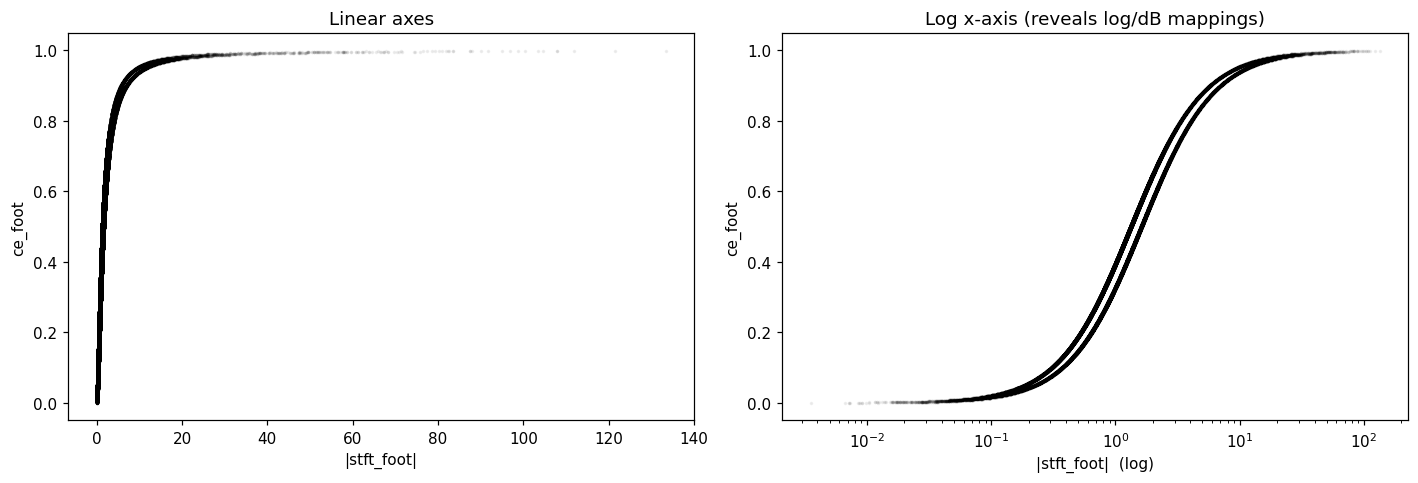

In [3]:
rng = np.random.default_rng(0)
N_SAMPLE = 80_000
flat_mag = mag.ravel()
flat_ce  = ce.ravel()
idx = rng.choice(flat_mag.size, size=N_SAMPLE, replace=False)
x = flat_mag[idx]
y = flat_ce[idx]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].scatter(x, y, s=2, alpha=0.05, c="k")
axes[0].set_xlabel("|stft_foot|")
axes[0].set_ylabel("ce_foot")
axes[0].set_title("Linear axes")

axes[1].scatter(x, y, s=2, alpha=0.05, c="k")
axes[1].set_xscale("log")
axes[1].set_xlabel("|stft_foot|  (log)")
axes[1].set_ylabel("ce_foot")
axes[1].set_title("Log x-axis (reveals log/dB mappings)")
plt.tight_layout(); plt.show()


### 1.2 Try element-wise fits

Candidates (most likely first):

| Family | Formula |
|---|---|
| dB | `ce = a · log10(x + eps) + b` |
| log1p | `ce = a · log(1 + b·x)` |
| gamma / power | `ce = a · x^γ` |
| linear | `ce = a · x + b` |
| cube root | `ce = a · x^(1/3)` |

R² closest to 1.0 wins. If the best R² is mediocre (< 0.95), the mapping isn't
purely element-wise → likely adaptive / windowed.

In [4]:
def r2(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - y_true.mean()) ** 2)
    return 1.0 - ss_res / (ss_tot + 1e-12)

# Use a subsample to keep curve_fit fast
x_fit, y_fit = x[:20_000], y[:20_000]
mask = x_fit > 0  # drop zeros for log fits
x_fit, y_fit = x_fit[mask], y_fit[mask]

fits = {}

def f_db(x, a, b): return a * np.log10(x) + b
def f_log1p(x, a, b): return a * np.log1p(b * x)
def f_gamma(x, a, g): return a * np.power(x, g)
def f_linear(x, a, b): return a * x + b
def f_cbrt(x, a, b): return a * np.cbrt(x) + b

for name, fn, p0 in [
    ("dB     ", f_db,     (1.0, 0.0)),
    ("log1p  ", f_log1p,  (1.0, 1.0)),
    ("gamma  ", f_gamma,  (1.0, 0.5)),
    ("linear ", f_linear, (1.0, 0.0)),
    ("cbrt   ", f_cbrt,   (1.0, 0.0)),
]:
    try:
        popt, _ = curve_fit(fn, x_fit, y_fit, p0=p0, maxfev=5000)
        yhat = fn(x_fit, *popt)
        fits[name] = {"R2": r2(y_fit, yhat), "params": popt, "fn": fn}
        print(f"  {name}  R²={fits[name]['R2']:+.4f}  params={popt}")
    except Exception as exc:
        print(f"  {name}  failed: {exc}")

best = max(fits, key=lambda k: fits[k]["R2"])
print(f"\nBest: {best}  (R² = {fits[best]['R2']:.4f})")


  dB       R²=+0.9178  params=[0.54749061 0.40228194]
  log1p    R²=+0.9127  params=[0.30349829 2.57073567]
  gamma    R²=+0.7883  params=[0.39292651 0.3829221 ]
  linear   R²=+0.3403  params=[0.03622137 0.36016641]
  cbrt     R²=+0.8329  params=[ 0.55344801 -0.17855008]

Best: dB       (R² = 0.9178)


### 1.3 Overlay the best fit on the scatter

If the curve hugs the cloud cleanly, we've identified the CE function.


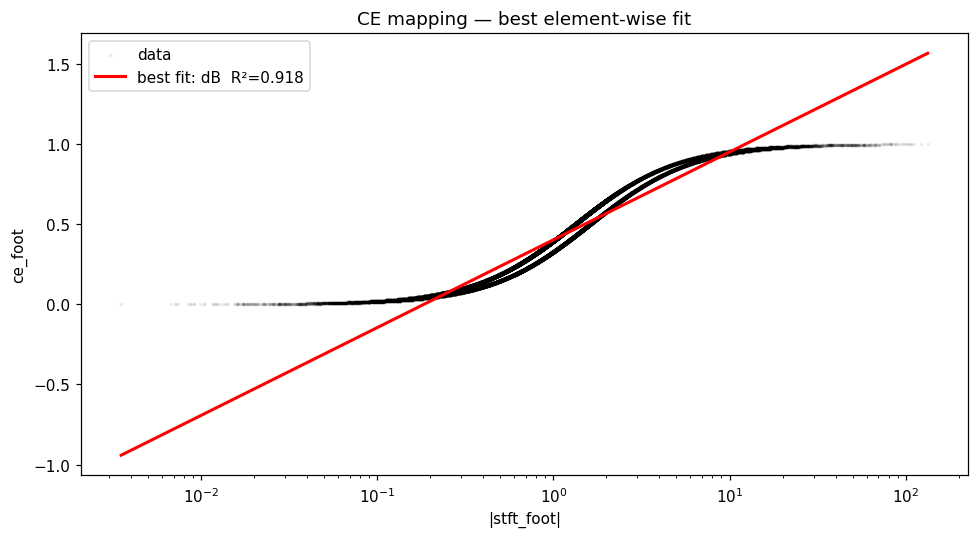

In [5]:
best_fn = fits[best]["fn"]
best_params = fits[best]["params"]

xs = np.linspace(max(x[x>0].min(), 1e-6), x.max(), 500)
ys = best_fn(xs, *best_params)

fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(x, y, s=2, alpha=0.05, c="k", label="data")
ax.plot(xs, ys, "r-", lw=2, label=f"best fit: {best.strip()}  R²={fits[best]['R2']:.3f}")
ax.set_xlabel("|stft_foot|")
ax.set_ylabel("ce_foot")
ax.set_xscale("log")
ax.legend()
ax.set_title("CE mapping — best element-wise fit")
plt.tight_layout()
plt.savefig(OUT_DIR / "11_ce_mapping_fit.png", dpi=120)
plt.show()


### 1.4 Does the same fit apply to torso? To other trials?

If yes → element-wise mapping (one formula for the whole dataset).
If no → mapping depends on the channel or is adaptive per trial.


In [6]:
def fit_residual(stft_abs, ce_arr, fn, p0):
    f, c = stft_abs.ravel(), ce_arr.ravel()
    m = f > 0
    f, c = f[m][:20000], c[m][:20000]
    popt, _ = curve_fit(fn, f, c, p0=p0, maxfev=5000)
    return r2(c, fn(f, *popt)), popt

# Try the best family on torso and on a few other trials
torso_mag = np.abs(trial["stft_torso"])
torso_ce  = trial["ce_torso"]

r2_torso, p_torso = fit_residual(torso_mag, torso_ce, best_fn, fits[best]["params"])
print(f"Torso, same trial:    R²={r2_torso:.4f}  params={p_torso}")

# Sample 4 random trials, run the same fit on their ce_foot
import random
random.seed(1)
trials = list(iter_trials())
sample = random.sample(trials, 4)
for tp in sample:
    tr = load_trial(tp.path, representation="both")
    m = np.abs(tr["stft_foot"])
    c = tr["ce_foot"]
    r2v, pv = fit_residual(m, c, best_fn, fits[best]["params"])
    print(f"  {tp.subject_id}/{tp.test}/{tp.trial}  R²={r2v:.4f}  params={pv}")


Torso, same trial:    R²=0.5396  params=[0.34033852 0.19849736]


  fisc_027/test1/trial3  R²=0.5150  params=[0.04081869 0.04751861]


  fisp_037/test1/trial3  R²=0.9451  params=[0.64711642 0.4671817 ]


  fisc_012/test1/trial3  R²=0.9015  params=[0.57711659 0.36117861]


  fisc_040/test2/trial2  R²=0.4594  params=[0.07137943 0.06836067]


### 1.5 Conclusion

If R² > 0.99 across foot + torso + multiple trials, **we have the formula** — write it down for the email to Ignacio.

If R² is high *within a trial* but the parameters vary across trials, the CE step normalises per-trial. If R² is mediocre everywhere, it's a 2D operation (windowed normalisation / CLAHE / per-frame).


## 2. Doppler zero-padding uniformity

Notebook 02 already checked this on one pass. Here we tighten: verify
**every** file has the same Doppler axis (size, range, bin spacing).


In [7]:
from tqdm.auto import tqdm
rows = []
for tp in tqdm(trials, desc="reading doppler_axis"):
    try:
        d = sio.loadmat(tp.path, variable_names=["doppler_axis"], squeeze_me=True)["doppler_axis"]
        d = np.asarray(d).ravel()
        rows.append({
            "subject_id": tp.subject_id, "group": tp.group,
            "test": tp.test, "trial": tp.trial,
            "n": int(d.size),
            "min": float(d.min()), "max": float(d.max()),
            "df": float(np.median(np.diff(d))) if d.size > 1 else float("nan"),
        })
    except Exception as e:
        rows.append({"subject_id": tp.subject_id, "test": tp.test, "trial": tp.trial,
                     "error": str(e), "n": -1})
dop_df = pd.DataFrame(rows)
print("size distribution:")
print(dop_df["n"].value_counts())
print("\nrange distribution:")
print(dop_df[["min", "max"]].drop_duplicates().head())
print("\nΔf distribution:")
print(dop_df["df"].describe())


reading doppler_axis:   0%|          | 0/348 [00:00<?, ?it/s]

size distribution:
n
320    348
Name: count, dtype: int64

range distribution:
           min         max
0  -794.872803  799.872009
48 -794.871399  799.870605

Δf distribution:
count    348.000000
mean       4.999198
std        0.000008
min        4.999191
25%        4.999191
50%        4.999191
75%        4.999207
max        4.999207
Name: df, dtype: float64


Are there *any* outliers? (Tightest criterion — every file should match.)

In [8]:
ref_n = dop_df["n"].mode().iloc[0]
ref_df = dop_df["df"].median()
outliers = dop_df[(dop_df["n"] != ref_n) | (np.abs(dop_df["df"] - ref_df) > 0.5)]
print(f"reference: n={ref_n}, Δf={ref_df:.2f} Hz")
print(f"outliers:  {len(outliers)}")
if len(outliers):
    print(outliers.head(20))


reference: n=320, Δf=5.00 Hz
outliers:  0


## 3. `param` struct + hidden-variable scan

The readme mentions `param` ("radar configuration parameters") but doesn't
list fields. Dump it. Also scan all files for variables that appear in
some but not others.


In [9]:
# 3.1 Dump param from one file
m = sio.loadmat(TRIAL, variable_names=["param"], squeeze_me=True)
param = m["param"]
print("type:", type(param).__name__, "dtype:", getattr(param, "dtype", "?"))
if hasattr(param, "dtype") and param.dtype.names:
    for field in param.dtype.names:
        val = param[field]
        if hasattr(val, "shape") and val.size > 5:
            print(f"  {field:24s}  shape={val.shape}  dtype={val.dtype}")
        else:
            print(f"  {field:24s}  {val}")
else:
    print(param)


type: ndarray dtype: [('nMuestras', 'O'), ('hora', 'O'), ('minutos', 'O'), ('indice', 'O'), ('Tramp', 'O'), ('Tcaptura', 'O'), ('nCanales', 'O'), ('TriggerMode', 'O'), ('InC1', 'O'), ('InC2', 'O'), ('InC3', 'O'), ('InC4', 'O'), ('DestinationPath', 'O'), ('Fs', 'O'), ('flyback', 'O'), ('BW', 'O'), ('ftrabajo', 'O'), ('deriva', 'O'), ('offset', 'O'), ('TrampTotal', 'O'), ('nMuestrasRamp', 'O'), ('c', 'O'), ('rampas_bloque', 'O'), ('p_muestras_iniciales_eliminadas', 'O'), ('p_muestras_finales_eliminadas', 'O'), ('nMuestrasCount', 'O'), ('angulo_rotacion', 'O'), ('tug', 'O'), ('offset_samples', 'O'), ('escala', 'O'), ('n_samples_ramp', 'O'), ('n_ramp', 'O')]
  nMuestras                 7500000
  hora                      9
  minutos                   28
  indice                    1
  Tramp                     0.000625
  Tcaptura                  15
  nCanales                  4
  TriggerMode               0
  InC1                      0
  InC2                      0
  InC3                

In [10]:
from tqdm.auto import tqdm
# 3.2 Variable inventory across all files
all_vars = []
for tp in tqdm(trials, desc="whosmat"):
    try:
        info = sio.whosmat(str(tp.path))
        all_vars.append(set(name for name, _, _ in info))
    except Exception:
        all_vars.append(set())

# union of variables seen, and per-variable count
var_count = {}
for vs in all_vars:
    for v in vs:
        var_count[v] = var_count.get(v, 0) + 1

n_files = len(trials)
print(f"Across {n_files} files:")
for v, c in sorted(var_count.items(), key=lambda kv: -kv[1]):
    flag = "" if c == n_files else "  <-- not in every file!"
    print(f"  {c:4d}/{n_files}  {v:24s}{flag}")


whosmat:   0%|          | 0/348 [00:00<?, ?it/s]

Across 348 files:
   348/348  all_fig_savename        
   348/348  all_loc                 
   348/348  all_fig_caption         
   348/348  idx_foot_max_snr        
   348/348  idx_torso_max_snr       
   348/348  doppler_axis            
   348/348  all_doppler_time        
   348/348  all_ce_time             
   348/348  ce_foot                 
   348/348  ce_torso                
   348/348  all_target_time         
   348/348  t_axis_target           
   348/348  stft_foot               
   348/348  all_dir                 
   348/348  param                   
   348/348  stft_torso              


## 4. `fisp_022/test1/trial4` forensics

Subject `fisp_022` has 7 files instead of 6 — an extra `test1/trial4`. Is
it a clean re-do, a different protocol, or a duplicate of an earlier trial?

We compare trial4 against trial1/2/3 of the same test, using:
- mean energy and duration
- cosine similarity on the flattened (downsampled) spectrogram
- visual side-by-side


In [11]:
SUBJ = "fisp_022"
test = "test1"
trials_022 = []
for trial_name in ("trial1", "trial2", "trial3", "trial4"):
    p = DATA_ROOT / SUBJ / test / trial_name / "stft_data.mat"
    if p.exists():
        trials_022.append((trial_name, load_trial(p)))
print([(n, tr["ce_foot"].shape, float(tr["t_axis"].max() - tr["t_axis"].min())) for n, tr in trials_022])


[('trial1', (320, 15191), 9.495268821716309), ('trial2', (320, 17920), 11.201166868209839), ('trial3', (320, 13947), 8.717644691467285), ('trial4', (320, 15415), 9.635291337966919)]


In [12]:
# Cosine similarity on a fixed-size downsample of ce_foot
from src.preprocessing import resize_2d

REF_SHAPE = (160, 256)
def cos_sim(a, b):
    a, b = a.ravel(), b.ravel()
    return float(np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b) + 1e-12))

specs = {n: resize_2d(np.log1p(tr["ce_foot"]), REF_SHAPE) for n, tr in trials_022}
keys = list(specs)
sim = np.zeros((len(keys), len(keys)))
for i, ki in enumerate(keys):
    for j, kj in enumerate(keys):
        sim[i, j] = cos_sim(specs[ki], specs[kj])
print(pd.DataFrame(sim, index=keys, columns=keys).round(3))


        trial1  trial2  trial3  trial4
trial1   1.000   0.824   0.863   0.820
trial2   0.824   1.000   0.839   0.833
trial3   0.863   0.839   1.000   0.825
trial4   0.820   0.833   0.825   1.000


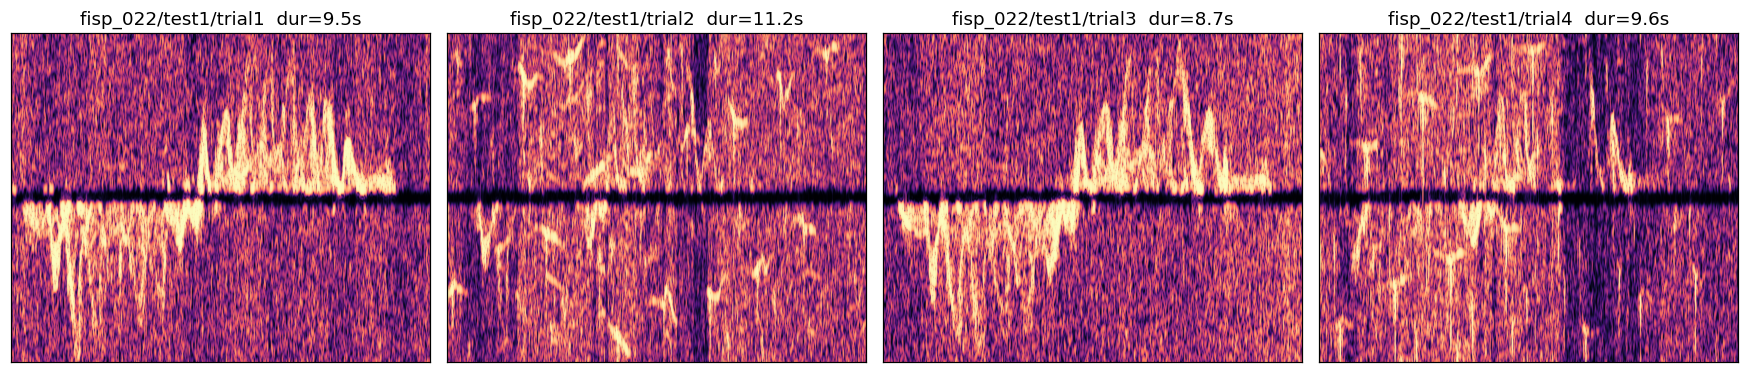

In [13]:
fig, axes = plt.subplots(1, 4, figsize=(16, 3.5), sharey=True)
for ax, (n, tr) in zip(axes, trials_022):
    ax.imshow(np.log1p(tr["ce_foot"]), aspect="auto", origin="lower", cmap="magma")
    dur = float(tr["t_axis"].max() - tr["t_axis"].min())
    ax.set_title(f"{SUBJ}/{test}/{n}  dur={dur:.1f}s")
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.savefig(OUT_DIR / "11_fisp022_trial4.png", dpi=120); plt.show()


**Interpretation**

If trial4's cosine similarity to one of trial1/2/3 is > 0.95, it's likely a duplicate (recommend exclude).
If similarities are all in the 0.6–0.85 band (the typical within-subject range), it's a clean retry (recommend keep).
If similarity is dramatically lower, trial4 may have a different protocol or noise pattern (flag for the team).


## 5. `fisp_048/test2/trial2` missing-trial forensics

trial2 is missing from `fisp_048/test2`. Two possible causes:
- File deleted during cleanup (acceptable; we drop it from analysis).
- File overwritten / corrupted at acquisition (trial1 == trial3 in disguise).

Compare trial1 and trial3 to see if they look like normal independent retries.


present in test2: ['trial1', 'trial3']


cosine similarity (trial1 vs trial3): 0.867


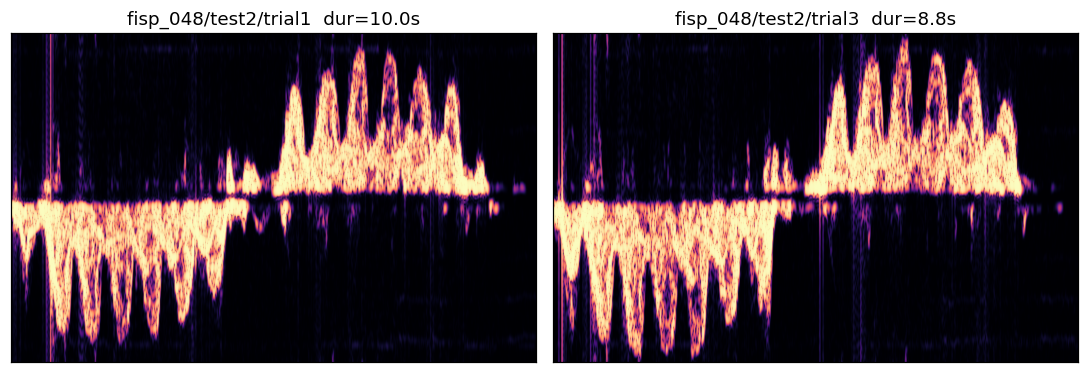

In [14]:
SUBJ48 = "fisp_048"
present = [t for t in (("trial1", ), ("trial2", ), ("trial3", )) if
           (DATA_ROOT / SUBJ48 / "test2" / t[0] / "stft_data.mat").exists()]
print("present in test2:", [t[0] for t in present])

if len(present) >= 2:
    pair = [load_trial(DATA_ROOT / SUBJ48 / "test2" / t[0] / "stft_data.mat") for t in present]
    s1 = resize_2d(np.log1p(pair[0]["ce_foot"]), REF_SHAPE)
    s2 = resize_2d(np.log1p(pair[1]["ce_foot"]), REF_SHAPE)
    print(f"cosine similarity (trial1 vs trial3): {cos_sim(s1, s2):.3f}")
    fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
    for ax, tr, n in zip(axes, pair, [t[0] for t in present]):
        ax.imshow(np.log1p(tr["ce_foot"]), aspect="auto", origin="lower", cmap="magma")
        dur = float(tr["t_axis"].max() - tr["t_axis"].min())
        ax.set_title(f"{SUBJ48}/test2/{n}  dur={dur:.1f}s")
        ax.set_xticks([]); ax.set_yticks([])
    plt.tight_layout(); plt.savefig(OUT_DIR / "11_fisp048_test2.png", dpi=120); plt.show()


**Interpretation**

Cosine similarity for an independent retry should sit in the same ~0.6–0.85
band as other within-subject pairs (see notebook 11 § 8). If trial1 and
trial3 of `fisp_048/test2` look like a normal retry pair, the missing
trial2 is almost certainly a clean deletion — safe to proceed with 5 files.


## 6. Doppler symmetry — is motion direction encoded?

The Doppler axis spans ±800 Hz. Positive Doppler = motion toward the radar;
negative = away. In TUG, the subject walks toward and away in the same
trial, so energy should populate both halves.

If `ce_foot` is **symmetric**, the dataset combines the two directions
(e.g. by taking |·| of the complex STFT before storage — which makes
sense given the file already provides `ce_*` as magnitudes).

> **Paper note (Fig. 6 caption):** for the two-torso-radar combination, *"prior to the combination, the Doppler-time matrix of node 2 is flipped with respect to the Doppler axis."* This deliberate flip collapses motion direction in the combined torso signal — so expect near-perfect symmetry in `ce_torso`. `ce_foot` is described only by the SNR-combination rule and may or may not show the same property.


In [15]:
from tqdm.auto import tqdm
# For each trial, compute energy in positive vs negative Doppler bins
sym_rows = []
for tp in tqdm(trials, desc="symmetry"):
    try:
        tr = load_trial(tp.path)
        d = tr["doppler"]
        ce = tr["ce_foot"]
        e_pos = float(ce[d > 0].sum())
        e_neg = float(ce[d < 0].sum())
        sym_rows.append({
            "subject_id": tp.subject_id, "group": tp.group,
            "test": tp.test, "trial": tp.trial,
            "pos_energy": e_pos, "neg_energy": e_neg,
            "ratio": e_pos / (e_neg + 1e-12),
        })
    except Exception:
        continue
sym_df = pd.DataFrame(sym_rows)
print(sym_df["ratio"].describe().round(3))


symmetry:   0%|          | 0/348 [00:00<?, ?it/s]

count    348.000
mean       1.005
std        0.043
min        0.752
25%        0.986
50%        1.005
75%        1.029
max        1.133
Name: ratio, dtype: float64


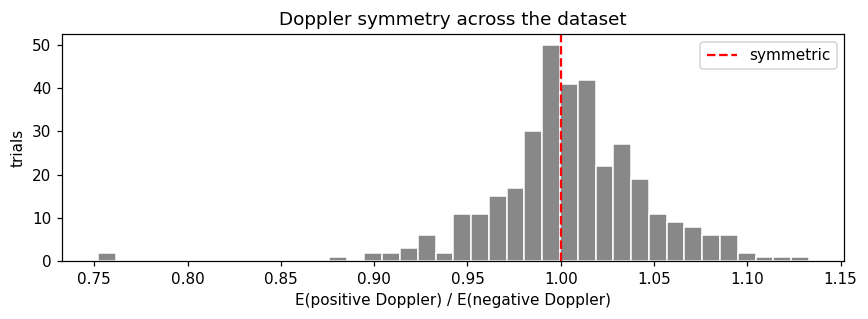


median ratio:  1.005


In [16]:
fig, ax = plt.subplots(figsize=(8, 3))
ax.hist(sym_df["ratio"], bins=40, color="#888", edgecolor="white")
ax.axvline(1.0, color="r", linestyle="--", label="symmetric")
ax.set_xlabel("E(positive Doppler) / E(negative Doppler)")
ax.set_ylabel("trials")
ax.set_title("Doppler symmetry across the dataset")
ax.legend()
plt.tight_layout(); plt.show()

# Median ratio — symmetric if ≈ 1
print(f"\nmedian ratio:  {sym_df['ratio'].median():.3f}")


**Interpretation**

- median ratio ≈ 1.0 → spectrograms are symmetric → direction is not preserved (consistent with `ce_*` being magnitude of an already-direction-collapsed STFT, or with TUG containing equal toward/away segments).
- median ratio noticeably off 1 → either dominant direction is encoded, or one of the foot radars contributed more energy.


## 7. Duration confound broken down by test

We know PD trials are ~10% longer on average. Is the gap dominated by
test1 (which involves standing up from a chair), by test2, or both?


In [17]:
from tqdm.auto import tqdm
# Read durations for all trials (cheap)
dur_rows = []
for tp in tqdm(trials, desc="durations"):
    try:
        t = sio.loadmat(tp.path, variable_names=["t_axis_target"], squeeze_me=True)["t_axis_target"]
        t = np.asarray(t).ravel()
        dur_rows.append({"subject_id": tp.subject_id, "group": tp.group,
                         "test": tp.test, "trial": tp.trial,
                         "duration_s": float(t.max() - t.min())})
    except Exception:
        continue
dur_df = pd.DataFrame(dur_rows)
print(dur_df.groupby(["test", "group"])["duration_s"].describe().round(2))


durations:   0%|          | 0/348 [00:00<?, ?it/s]

               count   mean   std   min   25%    50%    75%    max
test  group                                                       
test1 control   99.0   9.81  2.16  7.09  8.26   9.17  10.58  16.20
      pd        76.0  11.18  3.03  6.71  8.94  10.09  12.99  19.20
test2 control   99.0   8.30  1.69  5.80  7.00   8.04   9.07  13.26
      pd        74.0   8.83  2.13  6.06  7.34   8.31   9.56  15.65


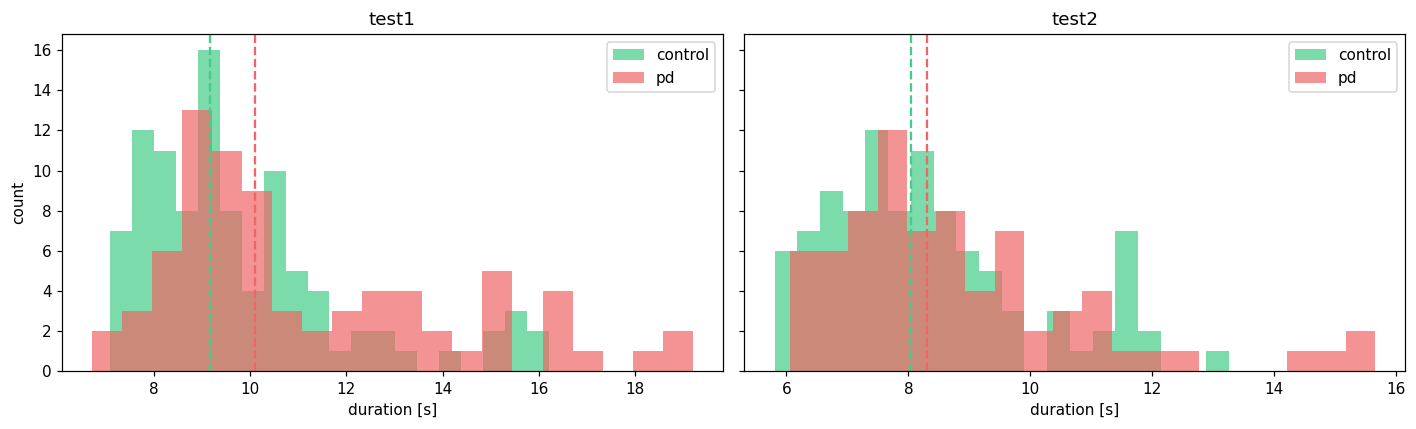

test1: ctrl=9.17s  pd=10.09s  → PD longer by +10.1%
test2: ctrl=8.04s  pd=8.31s  → PD longer by +3.4%


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)
for ax, test_name in zip(axes, ["test1", "test2"]):
    for grp, colour in [("control", "#4c8"), ("pd", "#e66")]:
        vals = dur_df[(dur_df.test == test_name) & (dur_df.group == grp)]["duration_s"]
        ax.hist(vals, bins=20, alpha=0.7, label=grp, color=colour)
        ax.axvline(vals.median(), color=colour, linestyle="--", lw=1.5)
    ax.set_xlabel("duration [s]")
    ax.set_title(test_name)
    ax.legend()
axes[0].set_ylabel("count")
plt.tight_layout(); plt.savefig(OUT_DIR / "11_duration_by_test.png", dpi=120); plt.show()

# Per-test medians + gap
for test_name in ["test1", "test2"]:
    sub = dur_df[dur_df.test == test_name]
    ctrl = sub[sub.group == "control"]["duration_s"].median()
    pd_  = sub[sub.group == "pd"]["duration_s"].median()
    pct = 100 * (pd_ - ctrl) / ctrl
    print(f"{test_name}: ctrl={ctrl:.2f}s  pd={pd_:.2f}s  → PD longer by {pct:+.1f}%")


## 8. Within-subject vs between-subject distance

How identifiable is one subject's gait? If `dist(trial_i, trial_j)` of the
same subject << `dist(trial_i, trial_k)` across subjects, subject identity
is a strong signal — and LOSO is the right protocol.

We compute per-trial feature vectors (using `src.features`, duration-invariant)
and measure mean Euclidean distance within-subject vs to random other
subjects.


In [19]:
from tqdm.auto import tqdm
feat_rows = []
for tp in tqdm(trials, desc="featurising"):
    try:
        tr = load_trial(tp.path)
        f = per_window_features(tr["ce_foot"], tr["ce_torso"], tr["doppler"])
        f.update({"subject_id": tp.subject_id, "group": tp.group,
                  "test": tp.test, "trial": tp.trial})
        feat_rows.append(f)
    except Exception:
        continue
feat_df = pd.DataFrame(feat_rows)
feature_cols = [c for c in feat_df.columns if c not in ("subject_id", "group", "test", "trial")]
print(f"{len(feat_df)} trials, {len(feature_cols)} features")


featurising:   0%|          | 0/348 [00:00<?, ?it/s]

348 trials, 21 features


In [20]:
from sklearn.preprocessing import StandardScaler

X = feat_df[feature_cols].values
mask = np.isfinite(X).all(axis=1)
X = X[mask]
meta = feat_df.loc[mask, ["subject_id", "group"]].reset_index(drop=True)

X_s = StandardScaler().fit_transform(X)

def mean_within(subj_id):
    rows = np.where(meta["subject_id"].values == subj_id)[0]
    if len(rows) < 2:
        return np.nan
    pts = X_s[rows]
    # mean pairwise distance, excluding self
    ds = np.linalg.norm(pts[:, None, :] - pts[None, :, :], axis=-1)
    mask = ~np.eye(len(rows), dtype=bool)
    return float(ds[mask].mean())

def mean_between(subj_id, k=10, seed=0):
    rng = np.random.default_rng(hash(subj_id) % (2**32) + seed)
    own = np.where(meta["subject_id"].values == subj_id)[0]
    others = np.where(meta["subject_id"].values != subj_id)[0]
    if not len(own) or not len(others):
        return np.nan
    pts = X_s[own].mean(axis=0)
    sample = rng.choice(others, size=min(k, len(others)), replace=False)
    return float(np.linalg.norm(X_s[sample] - pts, axis=-1).mean())

subjects = sorted(meta["subject_id"].unique())
rows = []
for s in subjects:
    rows.append({"subject_id": s,
                 "group": meta.loc[meta.subject_id == s, "group"].iloc[0],
                 "within": mean_within(s),
                 "between": mean_between(s)})
dist_df = pd.DataFrame(rows).dropna()
dist_df["ratio"] = dist_df["within"] / dist_df["between"]
print(dist_df.describe().round(3))


       within  between   ratio
count  58.000   58.000  58.000
mean    2.231    5.633   0.412
std     1.045    1.350   0.193
min     0.965    3.562   0.140
25%     1.518    4.944   0.250
50%     2.041    5.228   0.374
75%     2.715    6.103   0.541
max     6.898   11.271   0.973


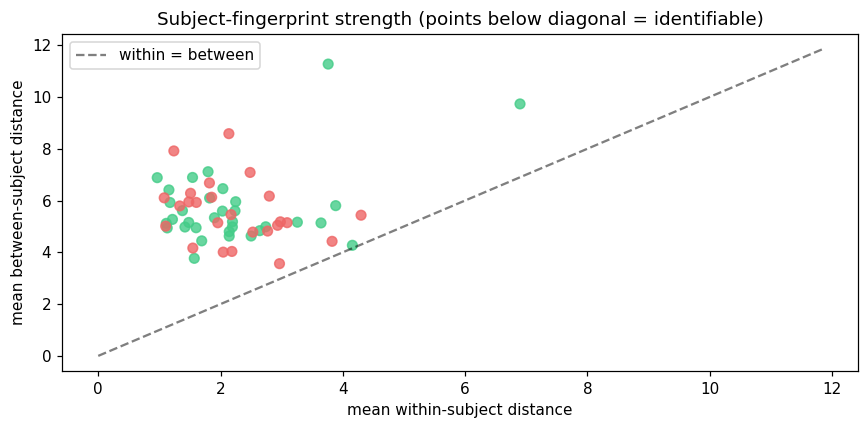


fraction with within < between: 1.00
median ratio:                  0.374


In [21]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.scatter(dist_df["within"], dist_df["between"],
           c=dist_df["group"].map({"control": "#4c8", "pd": "#e66"}),
           s=40, alpha=0.8)
lim = max(dist_df["within"].max(), dist_df["between"].max()) * 1.05
ax.plot([0, lim], [0, lim], "k--", alpha=0.5, label="within = between")
ax.set_xlabel("mean within-subject distance")
ax.set_ylabel("mean between-subject distance")
ax.legend()
ax.set_title("Subject-fingerprint strength (points below diagonal = identifiable)")
plt.tight_layout(); plt.savefig(OUT_DIR / "11_within_vs_between.png", dpi=120); plt.show()

print(f"\nfraction with within < between: {(dist_df['ratio'] < 1).mean():.2f}")
print(f"median ratio:                  {dist_df['ratio'].median():.3f}")


**Interpretation**

- All points well below the diagonal (ratio << 1) → strong subject fingerprint → LOSO is essential, k-fold would be misleading.
- Points scattered on/near the diagonal → individual trials are noisy, LOSO is still right but expect higher fold-to-fold variance.
- Any point *above* the diagonal → that subject's trials look more like other subjects than themselves; flag as a data-quality issue.


## Findings summary

Run all sections, then fill the table below with your numbers. This is the
artefact to attach when you email Ignacio.

| # | Question | Answer | Confidence |
|---|---|---|---|
| 1 | CE formula | (best fit family + R² + params) | (high if R² > 0.99) |
| 2 | Zero-padding uniformity | (n=320, Δf=5 Hz everywhere?) | |
| 3 | `param` fields + hidden vars | (list any variable not in every file) | |
| 4 | `fisp_022/test1/trial4` | (duplicate / clean retry / different) | |
| 5 | `fisp_048/test2/trial2` | (likely clean deletion / suspicious) | |
| 6 | Doppler symmetry | (median ratio ≈ ?) | |
| 7 | Duration gap by test | (test1: PD +x% ; test2: PD +y%) | |
| 8 | Subject fingerprint strength | (median within/between ratio) | |
